## Olof Sporn - Network Science Exploration

In [10]:
import os
import importlib
import numpy as np, pandas as pd, networkx as nx
import Project1.A3.desikan_killiany_atlas as dkatlas
import Project1.A3.utils_a3 as utils
# import Project1.A3.watts_in_adni as nwm
from collections import defaultdict
import Project1.A3.utils_a1_a3 as utils_a1
# import Project1.A3.gudhi_persistence_a3 as gp_a1
import Project1.A1.network_science as nc
import matplotlib.pyplot as plt
import lifelines
from sklearn.decomposition import PCA
import community as community_louvain
import warnings
PATH = os.getcwd()
BASE_DIR = utils.BASE_DIR
print(f"utils base directory: {BASE_DIR}")

utils base directory: C:\Users\sranasin\PycharmProjects\NetworkModels


In [11]:
# reload all
importlib.reload(utils); # importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(nc)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'Project1.A3.desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [3]:
params_temp_list = {'num_nodes': 100, 'num_neighbor_nodes': 1, 'total_random_edges': 50, 'distance_threshold': 2,
                    'weighted': True, 'ngeo_placement': 'random.choice', 'n_seeds': 1, 'node_active_threshold': 0.05,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2, 'seeding_method': 'all_combinations',
                    'threshold_sum': sum(range(83)) - 300}

In [4]:
df_raw, _ = nc.main_sims([params_temp_list])

Simulating Contagion Map for simulation: 0/1


In [5]:
df_raw

,time,state,num_active_nodes,active_nodes,H_0,H_1,H_2,realization_id,seed_nodes,num_nodes,...,skew_power,seed_cluster_distance,ngeom_edges_in_persistence,max_persistence_dim,seeding_method,threshold_sum,simulation_id,average_weight_per_edge,total_geo_edges,total_non_geo_edges
0,0,0,1,[0],0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
1,1,0,2,"[0, 2]",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
2,2,0,6,"[0, 2, 3, 4, 7, 8]",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
3,3,0,38,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
4,4,0,75,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,2,0,10,"[65, 66, 67, 68, 69, 70, 71, 73, 81, 63]",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
378,3,0,35,"[41, 44, 45, 46, 47, 48, 49, 50, 55, 56, 57, 5...",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
379,4,1,75,"[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
380,5,1,83,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132


In [6]:
df_raw['seed_nodes'] = df_raw['seed_nodes'].str[0]
df = df_raw[['realization_id', 'seed_nodes', 'time', 'state', 'num_active_nodes', 'active_nodes', 'threshold_sum', 'node_active_threshold']]
df

,realization_id,seed_nodes,time,state,num_active_nodes,active_nodes,threshold_sum,node_active_threshold
0,0,0,0,0,1,[0],3103,0.05
1,0,0,1,0,2,"[0, 2]",3103,0.05
2,0,0,2,0,6,"[0, 2, 3, 4, 7, 8]",3103,0.05
3,0,0,3,0,38,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",3103,0.05
4,0,0,4,0,75,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",3103,0.05
...,...,...,...,...,...,...,...,...
377,81,81,2,0,10,"[65, 66, 67, 68, 69, 70, 71, 73, 81, 63]",3103,0.05
378,81,81,3,0,35,"[41, 44, 45, 46, 47, 48, 49, 50, 55, 56, 57, 5...",3103,0.05
379,81,81,4,1,75,"[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",3103,0.05
380,81,81,5,1,83,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",3103,0.05


### Network Properties (Local)

In [7]:
graph, _ = nc.simulate_contagion_map(params_temp_list)
graph.nodes(data=True)[0]

{'dn_position_x': 34.0419230769,
 'dn_position_y': 82.1757692308,
 'dn_position_z': 31.7769230769,
 'dn_correspondence_id': 1,
 'dn_region': 'cortical',
 'dn_fsname': 'lateralorbitofrontal',
 'dn_name': 'rh.lateralorbitofrontal',
 'dn_hemisphere': 'right',
 'region_name': 'rh_lateralorbitofrontal'}

In [8]:
list(graph.edges(data=True))[0:1]

[(0,
  1,
  {'number_of_fibers': 5.62910798122,
   'FA_mean': 0.178233936269,
   'fiber_length_std': 0.816500084943,
   'fiber_length_mean': 15.9575699282,
   'FA_std': 0.116142955546,
   'weight': 0.35275471181061957,
   'type': 'geometric'})]

In [13]:
def participation_coefficient(graph, partition):
    """
    Participation coefficient for each node.
    P(i) = 1 - sum((k_is / k_i)^2)
    where k_is = strength of connections from node i to community s
          k_i  = total strength of connections from node i
    P = 0 -> all connections within same community (provincial hub)
    P = 1 -> connections spread across all communities (connector hub)
    """
    participation = {}

    for node in graph.nodes():
        total_strength = sum(data.get('weight_fa', 1) for _, _, data in graph.edges(node, data=True))

        if total_strength == 0:
            participation[node] = 0.0
            continue

        # Sum strength per community
        community_strength = {}
        for _, neighbor, data in graph.edges(node, data=True):
            community = partition[neighbor]
            strength = data.get('weight_fa', 1)
            community_strength[community] = community_strength.get(community, 0) + strength

        # P = 1 - sum((k_is / k_i)^2)
        participation[node] = 1 - sum(
            (s / total_strength) ** 2
            for s in community_strength.values()
        )

    return participation

In [26]:
w_max

3.99815708697968

In [29]:
for u, v, data in graph.edges(data=True):
    data['weight'] = data['number_of_fibers'] / data['fiber_length_mean']
    data['weight_fa'] = data['number_of_fibers'] * data['FA_mean'] / data['fiber_length_mean']

weights_fa = [data['weight_fa'] for u, v, data in graph.edges(data=True)]
w_max = max(weights_fa)
threshold = np.percentile(weights_fa, 5)
for u, v, data in graph.edges(data=True):
    data['distance'] = 1.0 / max(data['weight_fa']/w_max, threshold) # inverse metric to weight


degree = dict(graph.degree(weight='weight_fa')) # weighted degree (as opposed to normal)
clustering = nx.clustering(graph, weight='weight_fa')

# both betweenness and closeness use shortest path (or strongest path)(minimize edge values) to connect, we need to invert a weight (so we use 1/weight)
betweenness = nx.betweenness_centrality(graph, weight='distance', normalized=True)
closeness = nx.closeness_centrality(graph, distance='distance')

# higher_q = more within community edges vs (change edges)
# initialized over 100 (or whatever) to reduce random seed chance
best_partition = None
best_modularity = -1
for k in range(100):
    partition = community_louvain.best_partition(graph, weight='weight_fa', resolution=0.5)
    q = community_louvain.modularity(partition, graph, weight='weight_fa')
    if q > best_modularity:
        best_modularity = q
        best_partition = partition

print(f"Modularity Q: {best_modularity}, Communities: {len(set(best_partition.values()))}")

participation = participation_coefficient(graph, best_partition)


Modularity Q: 0.4781777728065795, Communities: 9


In [30]:
df_props = pd.DataFrame({
    'degree': degree,
    'clustering': clustering,
    'betweenness': betweenness,
    'closeness': closeness,
    'module': best_partition,
    'participation': participation
})

df_props.index.name = 'node_id'
df_props = df_props.reset_index()

In [31]:
# Complete detailed table
node_attrs = pd.DataFrame.from_dict(dict(graph.nodes(data=True)), orient='index')
node_attrs = node_attrs.reset_index().rename(columns = {'index':'node_id'})
df_dk_detailed = df_props.merge(node_attrs, left_on='node_id', right_on = 'node_id', how = 'left')

In [40]:
print(df_dk_detailed.nsmallest(10, 'participation')[['dn_fsname', 'degree', 'betweenness', 'closeness', 'participation']])

           dn_fsname    degree  betweenness  closeness  participation
20            cuneus  0.860469     0.000000   0.022836       0.003563
1      parsorbitalis  0.336504     0.000000   0.015985       0.009037
21     pericalcarine  2.235848     0.000000   0.025109       0.013991
42     parsorbitalis  0.270189     0.000000   0.015585       0.019777
2        frontalpole  0.032941     0.000000   0.004167       0.028959
82        Brain-Stem  2.728214     0.000000   0.031592       0.063061
22  lateraloccipital  4.492922     0.033123   0.027166       0.108603
43       frontalpole  0.020806     0.000000   0.001951       0.142314
45  parstriangularis  2.710796     0.000000   0.028010       0.151369
4   parstriangularis  2.300794     0.024390   0.028768       0.154366


In [41]:
subcortical = ['Right-Putamen', 'Left-Putamen', 'Right-Caudate', 'Left-Caudate',
               'Right-Thalamus-Proper', 'Left-Thalamus-Proper', 'Right-Pallidum',
               'Left-Pallidum', 'Right-Hippocampus', 'Left-Hippocampus',
               'Right-Amygdala', 'Left-Amygdala', 'Right-Accumbens-area', 'Left-Accumbens-area']

df_cortical = df_dk_detailed[~df_dk_detailed['dn_fsname'].isin(subcortical)]
print(df_cortical.nlargest(10, 'degree')[['dn_fsname', 'degree', 'betweenness', 'closeness']])

               dn_fsname     degree  betweenness  closeness
50            precentral  13.191902     0.168323   0.035146
9             precentral  13.187345     0.130684   0.034907
58      superiorparietal  10.232322     0.101475   0.031496
17      superiorparietal   9.916834     0.059922   0.030768
33                insula   7.985206     0.169828   0.034435
48       superiorfrontal   7.681825     0.001807   0.032211
49   caudalmiddlefrontal   7.590651     0.001204   0.034238
6   rostralmiddlefrontal   7.568824     0.066546   0.032686
7        superiorfrontal   7.205572     0.001807   0.030778
18      inferiorparietal   7.106480     0.127974   0.031190


### PRepare for Cox-PH (Not time varying)

In [42]:
def collapse_run(run):
    run = run.sort_values("time")

    # Check if event occurred
    event_rows = run[run["state"] == 1]

    if len(event_rows) > 0:
        event = 1
        first_event_row = event_rows.iloc[0]
        duration = first_event_row["time"]
        active_at_event = first_event_row["num_active_nodes"]
    else:
        event = 0
        last_row = run.iloc[-1]
        duration = last_row["time"]
        active_at_event = last_row["num_active_nodes"]

    return pd.Series({
        "duration": duration,
        "event": event,
        "active_at_event": active_at_event})


In [43]:
warnings.filterwarnings("ignore")
survival_df = (
    df
    .groupby("seed_nodes", as_index=False)
    .apply(collapse_run)
    .reset_index(drop=True)
)
survival_df

,seed_nodes,duration,event,active_at_event
0,0,5,1,83
1,1,0,0,1
2,2,0,0,1
3,3,5,1,83
4,4,5,1,83
...,...,...,...,...
78,78,0,0,1
79,79,4,1,78
80,80,4,1,76
81,81,4,1,75


In [47]:
df_cox = survival_df.merge(df_props, left_on="seed_nodes", right_on="node_id", how="left")
df_cox.drop(columns=["seed_nodes", 'node_id'], inplace=True)
df_cox.head(10)

,duration,event,active_at_event,degree,clustering,betweenness,closeness,module,participation
0,5,1,83,3.938717,0.007457,0.000000,0.032893,0,0.216794
1,0,0,1,0.336504,0.001941,0.000000,0.015985,0,0.009037
2,0,0,1,0.032941,0.001424,0.000000,0.004167,0,0.028959
3,5,1,83,1.815338,0.004238,0.024390,0.026772,0,0.341272
4,5,1,83,2.300794,0.003926,0.024390,0.028768,0,0.154366
5,5,1,83,2.622551,0.006699,0.000000,0.029256,0,0.326355
6,5,1,83,7.568824,0.008605,0.066546,0.032686,0,0.227727
7,5,1,83,7.205572,0.014555,0.001807,0.030778,0,0.318955
8,5,1,83,6.096464,0.012090,0.000000,0.032534,0,0.291997
9,5,1,83,13.187345,0.012988,0.130684,0.034907,0,0.348611


## Run cox-PH models

In [49]:
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

cph = CoxPHFitter()
cols = [c for c in df_cox.columns if c not in ['duration', 'event', 'active_at_event']]
scaler = StandardScaler()
df_cox[cols] = scaler.fit_transform(df_cox[cols])

In [50]:
cph.fit(df_cox, duration_col = "duration", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 83 total observations, 20 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 83
number of events observed = 63
   partial log-likelihood = -191.85
         time fit was run = 2026-02-23 08:17:24 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
active_at_event -0.10      0.90      0.04           -0.18           -0.02                0.84                0.98
degree          -0.24      0.79      0.47           -1.16            0.69                0.31                1.98
clustering       0.10      1.10      0.31           -0.50            0.70                0.61                2.01
betweenness      0.29      1.33      0.31           -0.31            0.88                0.73                2.42
closeness        0.21      1.23      0.20           -0.19            0.61                0.82                1.84
module           0.31      1.37      0.17           -0.02            0.64                0.98                1.90
participation    0.12      1.13      0.19           -0.25            0.49                0.78                1.63

                 cmp to     z    p  -log2(p)
covariate                                   
active_at_event    0.00 -2.47 0.01      6.22
degree             0.00 -0.50 0.62      0.70
clustering         0.00  0.32 0.75      0.42
betweenness        0.00  0.93 0.35      1.51
closeness          0.00  1.02 0.31      1.69
module             0.00  1.85 0.06      3.95
participation      0.00  0.65 0.52      0.95
---
Concordance = 0.98
Partial AIC = 397.70
log-likelihood ratio test = 18.32 on 7 df
-log2(p) of ll-ratio test = 6.56

<Axes: xlabel='log(HR) (95% CI)'>

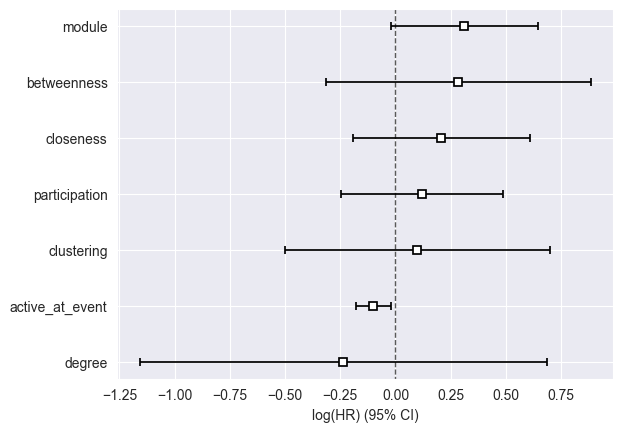

In [51]:
cph.plot()

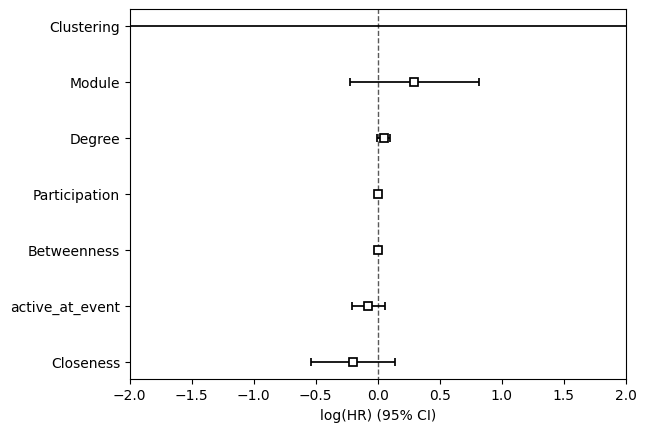

In [134]:
# # before scaling
#
# ax = cph.plot()
# ax.set_xlim(-2, 2)
# plt.show()